# TASK 1: IRIS FLOWER CLASSIFICATION
# STEP 1: Data Collection & Dataset Preparation: Importing Libraries, Loading Iris Dataset and Creating DataFrame

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Step 2: Data Understanding & Exploration: Checking Dataset Shape, Data Types, Missing Values and Descriptive Statistics

In [4]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n", df.describe())

Shape: (150, 6)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name             str
dtype: object

Null values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Descriptive statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

    

# Step 3: Exploratory Data Analysis (EDA): Visualizing Feature Relationships Using Pairplot


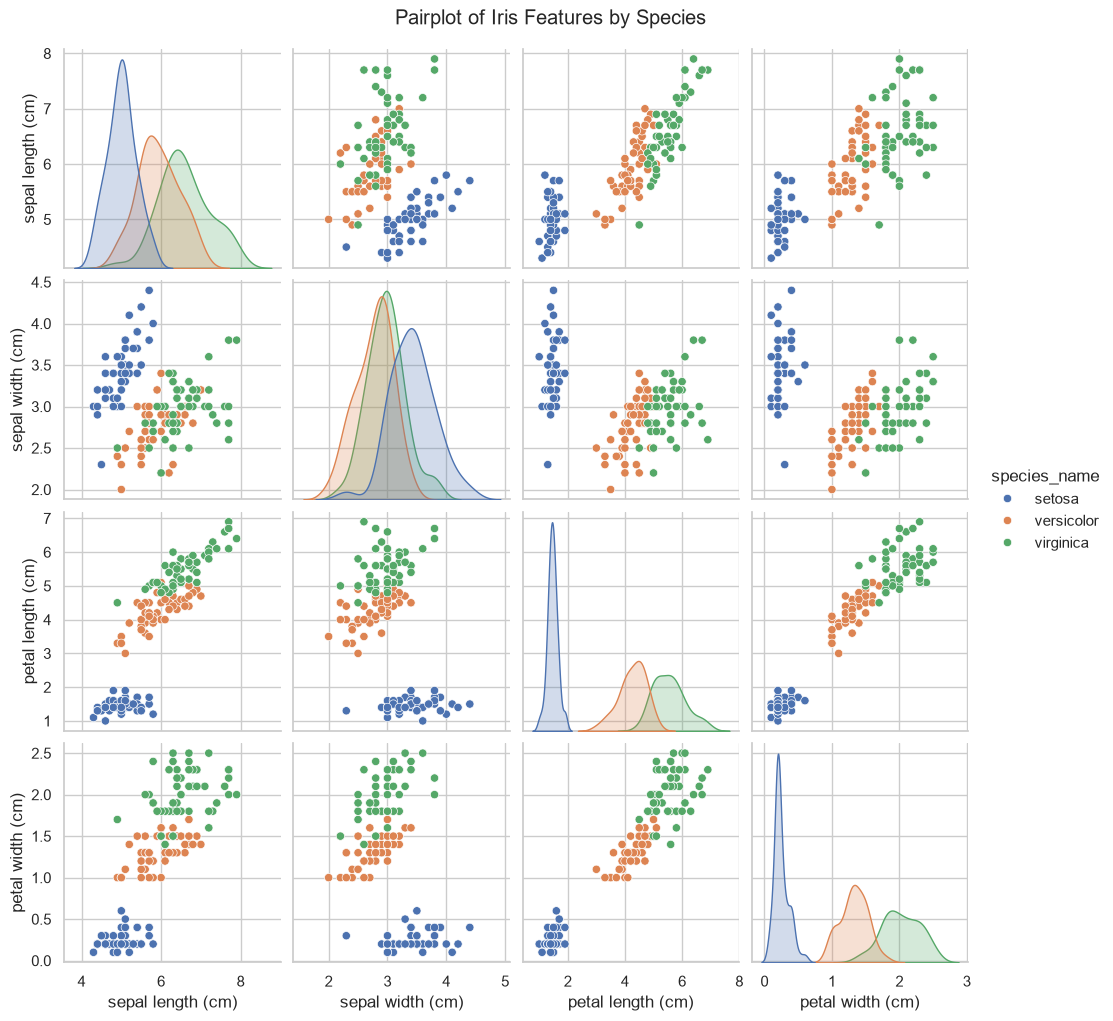

In [5]:
sns.pairplot(df, hue='species_name', vars=iris.feature_names)
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

# Step 4: Data Distribution & Outlier Analysis: Comparing Iris Features Across Species Using Boxplots

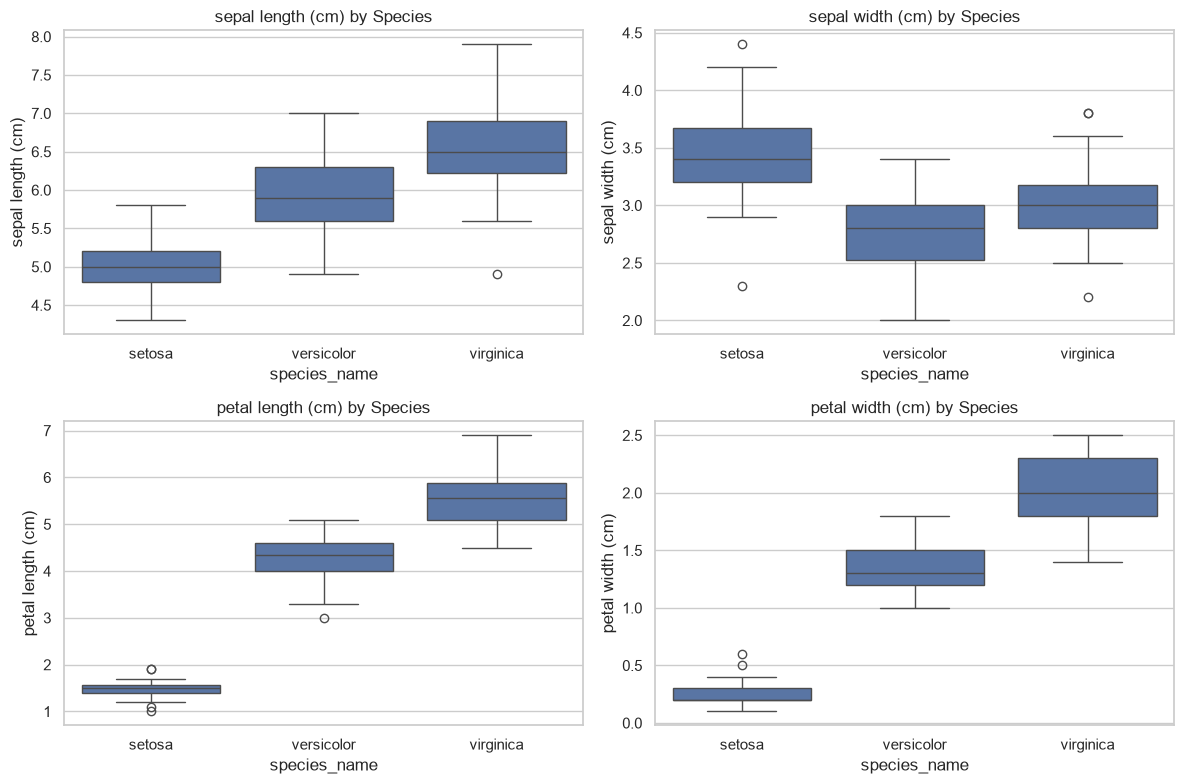

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=df, x='species_name', y=col, ax=ax)
    ax.set_title(f'{col} by Species')
plt.tight_layout()
plt.show()


Based on the pairplot and box plots, petal length and petal width are the 
most discriminative features — they show the least overlap in distribution 
across species. Sepal measurements overlap more between Versicolor and 
Virginica, making them less reliable predictors on their own.



# Step 5: Data Preparation & Train-Test Split: Separating Features and Target and Splitting the Dataset


In [7]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 120 | Test size: 30


# Step 6:Model Building & Performance Evaluation: Training Logistic Regression and KNN Models and Evaluating Predictions

In [10]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=iris.target_names))
    print()

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn)

--- Logistic Regression ---
Accuracy: 0.9666666666666667

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


--- K-Nearest Neighbors ---
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      

# Step 7 : Model Performance Visualization: Visualizing Logistic Regression and KNN Confusion Matrices 

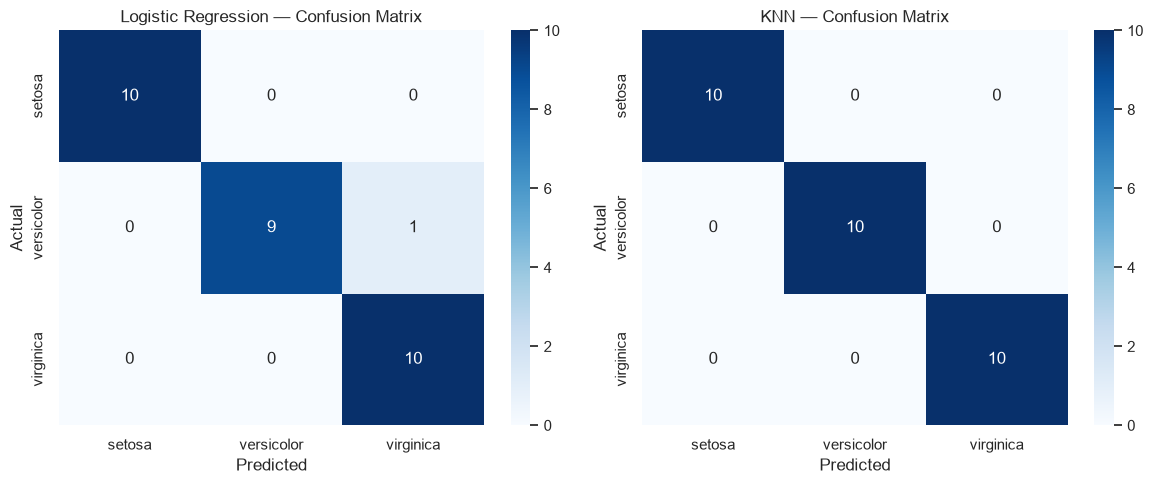

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, preds) in zip(axes, [("Logistic Regression", y_pred_lr), ("KNN", y_pred_knn)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

Best model: Both Logistic Regression and K-Nearest Neighbors achieved 
100% accuracy on the test set, with perfect precision, recall, and 
F1-scores across all three species.

Why: Given the identical performance, Logistic Regression is the 
slightly preferable choice for deployment — it's simpler, faster to 
train, and more interpretable (via its coefficients) than KNN, while 
matching KNN's accuracy exactly on this dataset. The near-perfect 
separability of the Iris classes (especially by petal measurements) 
makes this an easy classification problem for either algorithm.